In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split

In [32]:

df = pd.read_csv('Train.csv')

X = df.drop("Reached.on.Time_Y.N", axis=1)
y = df["Reached.on.Time_Y.N"]
print("Original Shape:", X.shape)

Original Shape: (10999, 11)


In [33]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'string']).columns

In [34]:
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [35]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Fit ONLY on train (correct practice)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Train Shape:", X_train_processed.shape)

Processed Train Shape: (8799, 20)


In [36]:
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso_model.fit(X_train_processed)

iso_pred = iso_model.predict(X_test_processed)

# Convert: -1 → anomaly(1), 1 → normal(0)
iso_pred = np.where(iso_pred == -1, 1, 0)

print("\nIsolation Forest Results:")
print("Anomalies detected:", np.sum(iso_pred))


Isolation Forest Results:
Anomalies detected: 94


In [37]:
svm_model = OneClassSVM(kernel='rbf', gamma=0.01)

svm_model.fit(X_train_processed)

svm_pred = svm_model.predict(X_test_processed)
svm_pred = np.where(svm_pred == -1, 1, 0)

print("\nOne-Class SVM Results:")
print("Anomalies detected:", np.sum(svm_pred))


One-Class SVM Results:
Anomalies detected: 1092


In [38]:
gammas = [0.001, 0.01, 0.1]

print("\nGamma Tuning:")
for g in gammas:
    model = OneClassSVM(kernel='rbf', gamma=g)
    model.fit(X_train_processed)

    pred = model.predict(X_test_processed)
    pred = np.where(pred == -1, 1, 0)

    print(f"Gamma = {g}, Anomalies detected:", np.sum(pred))


Gamma Tuning:
Gamma = 0.001, Anomalies detected: 1093
Gamma = 0.01, Anomalies detected: 1092
Gamma = 0.1, Anomalies detected: 1085


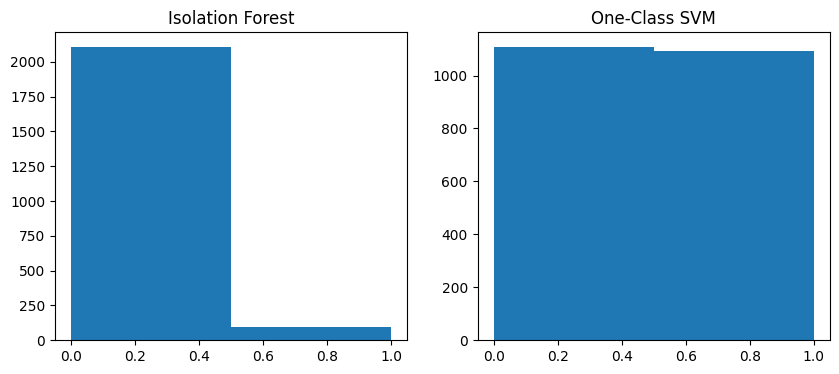

In [39]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(iso_pred, bins=2)
plt.title("Isolation Forest")

plt.subplot(1,2,2)
plt.hist(svm_pred, bins=2)
plt.title("One-Class SVM")

plt.show()